# Flight Delay Prediction - Classifier Training

This notebook trains the binary delay classifier using the cleaned dataset produced by `01_eda.ipynb`.

Expected input:

```text
../data/flight_features_cleaned_for_modeling.csv
```

The cleaned dataset is built from the current `../flight_features.csv` export and includes the new historical rolling delay features. Those features are allowed only because they are historical aggregates; target columns, post-event fields, raw timestamps, and identifiers remain excluded from `X`.

Main responsibilities:

1. Load the cleaned dataset.
2. Validate target, timestamp, leakage columns, and rolling feature presence.
3. Prepare `X` and `y`.
4. Use chronological train/test split.
5. Train baseline models.
6. Tune models with time-aware cross-validation.
7. Tune the final decision threshold.
8. Save model, metrics, metadata, and plots.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates.extend(path for path in cwd.iterdir() if path.is_dir())
    for candidate in candidates:
        if (candidate / "flight_features.csv").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd.parent if cwd.name == "notebooks" else cwd


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
MEDIA_DIR = PROJECT_DIR / "media" / "training"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MEDIA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

print("Setup completed.")
print("DATA_DIR:", DATA_DIR.resolve())
print("MODEL_DIR:", MODEL_DIR.resolve())
print("MEDIA_DIR:", MEDIA_DIR.resolve())

Setup completed.
DATA_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data
MODEL_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models
MEDIA_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\media\training


## 1. Load cleaned dataset

This notebook expects that `01_eda.ipynb` has already created the cleaned modeling dataset.

The training notebook does not repeat the full cleaning logic from EDA.

In [2]:
CLEAN_PATH = DATA_DIR / "flight_features_cleaned_for_modeling.csv"

if not CLEAN_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEAN_PATH}\n"
        "Run 01_eda.ipynb first and make sure it saves "
        "flight_features_cleaned_for_modeling.csv into ../data/"
    )

df = pd.read_csv(CLEAN_PATH)

print(f"Cleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())
display(df.dtypes.value_counts().to_frame("n_columns"))

Cleaned dataset shape: 9,939 rows × 66 columns


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,dep_delay_min,is_delayed,dep_latitude,dep_longitude,dep_elevation_ft,dep_iso_country,...,airline_delay_rate_7d_missing,dep_airport_avg_delay_7d_missing,dep_airport_avg_delay_30d_missing,dep_airport_delay_rate_7d_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,2026-04-10 00:05:00+00:00,SVO,ALA,SU,36.0,1,55.976858,37.411210,622.0,RU,...,0,0,0,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,2026-04-10 00:40:00+00:00,IST,ALA,TK,19.0,1,41.274874,28.732136,325.0,TR,...,0,0,0,0,IST,ALA,TK,IST_ALA,TR,KZ
2,2026-04-10 00:40:00+00:00,IST,ALA,KC,19.0,1,41.274874,28.732136,325.0,TR,...,0,0,0,0,IST,ALA,KC,IST_ALA,TR,KZ
3,2026-04-10 00:40:00+00:00,IST,ALA,MS,19.0,1,41.274874,28.732136,325.0,TR,...,1,0,0,0,IST,ALA,MS,IST_ALA,TR,KZ
4,2026-04-10 00:50:00+00:00,LED,ALA,FV,16.0,1,59.800301,30.262501,78.0,RU,...,1,1,1,1,LED,ALA,FV,LED_ALA,RU,KZ


,n_columns
float64,25
int64,23
object,18


## 2. Basic modeling checks

We check:

- target exists,
- target is binary,
- timestamp exists,
- obvious leakage columns are handled.

If columns like `is_delayed_int` remained from EDA helper conversions, they are removed from features later.

In [3]:
TARGET_COL = "is_delayed"
TIME_COL = "dep_scheduled_utc"

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' was not found in cleaned dataset.")

if TIME_COL not in df.columns:
    raise ValueError(
        f"Column '{TIME_COL}' was not found in cleaned dataset. "
        "Go back to 01_eda.ipynb and keep dep_scheduled_utc in "
        "flight_features_cleaned_for_modeling.csv. It is needed for chronological split."
    )

# Normalize target to 0/1 integer.
if df[TARGET_COL].dtype == "object":
    df[TARGET_COL] = df[TARGET_COL].map({
        "t": 1, "f": 0,
        "True": 1, "False": 0,
        True: 1, False: 0,
        "1": 1, "0": 0,
        1: 1, 0: 0,
    })

if df[TARGET_COL].isna().any():
    raise ValueError("Target column contains missing values. Fix it in 01_eda.ipynb.")

df[TARGET_COL] = df[TARGET_COL].astype(int)

unique_target_values = sorted(df[TARGET_COL].unique().tolist())
print("Unique target values:", unique_target_values)

if set(unique_target_values) != {0, 1}:
    raise ValueError("Target must contain only 0/1 values.")

print("Target distribution:")
display(df[TARGET_COL].value_counts().to_frame("count"))
display((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).to_frame("percent"))

print("Total missing values in full cleaned dataset:", int(df.isna().sum().sum()))

if df.isna().sum().sum() > 0:
    print("\nColumns with missing values:")
    display(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False).to_frame("missing_count"))

print("\nExpected split timestamp column:", TIME_COL)

Unique target values: [0, 1]
Target distribution:


,count
is_delayed,
0,5392
1,4547


,percent
is_delayed,
0,54.25
1,45.75


Total missing values in full cleaned dataset: 0

Expected split timestamp column: dep_scheduled_utc


## 3. Chronological split timestamp

The cleaned dataset must contain `dep_scheduled_utc`.

This timestamp is used only for chronological train/test split.  
It is not used as a model feature.

This is important because the model should be evaluated on future flights, not on randomly mixed past and future observations.

In [4]:
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

missing_time = df[TIME_COL].isna().sum()
print(f"Missing {TIME_COL}: {missing_time:,}")

if missing_time > 0:
    raise ValueError(
        f"{TIME_COL} contains missing or invalid timestamps. "
        "Fix timestamp parsing in 01_eda.ipynb before training."
    )

split_strategy_note = (
    "Chronological split using dep_scheduled_utc from cleaned dataset. "
    "The timestamp is used only for sorting and is not used as a model feature."
)

print(split_strategy_note)

print("\nTimestamp range:")
print("min:", df[TIME_COL].min())
print("max:", df[TIME_COL].max())

Missing dep_scheduled_utc: 0
Chronological split using dep_scheduled_utc from cleaned dataset. The timestamp is used only for sorting and is not used as a model feature.

Timestamp range:
min: 2026-04-10 00:05:00+00:00
max: 2026-05-10 23:55:00+00:00


## 4. Prepare X and y

We remove from model features:

- target,
- timestamp,
- leakage columns,
- target duplicates,
- raw high-cardinality columns if grouped versions exist,
- temporary `_int` helper columns created during EDA.

This keeps modeling cleaner and avoids unnecessary leakage or memorization.

In [5]:
leakage_or_forbidden_cols = [
    "is_delayed_int",       # target duplicate from EDA helper conversion
    "dep_delay_min",        # target source
    "status",               # post-event outcome
    "updated_at",           # technical metadata
    "flight_iata",          # ID-like memorization risk
    "flight_number",        # ID-like memorization risk
    "airline_icao",         # redundant if airline_iata exists
    "dep_terminal",         # high missingness in EDA
]

present_forbidden = [c for c in leakage_or_forbidden_cols if c in df.columns]

print("Forbidden / leakage columns found and will be dropped from features:")
print(present_forbidden)

columns_to_drop_from_X = [TARGET_COL, TIME_COL] + present_forbidden
columns_to_drop_from_X = [c for c in columns_to_drop_from_X if c in df.columns]

X_all = df.drop(columns=columns_to_drop_from_X).copy()
y_all = df[TARGET_COL].copy()

# If grouped categorical versions exist, drop raw high-cardinality versions.
# Example: use dep_iata_grp instead of dep_iata.
raw_to_grouped_pairs = {
    "dep_iata": "dep_iata_grp",
    "arr_iata": "arr_iata_grp",
    "airline_iata": "airline_iata_grp",
    "route": "route_grp",
    "dep_iso_country": "dep_iso_country_grp",
    "arr_iso_country": "arr_iso_country_grp",
}

raw_cols_to_drop = [
    raw_col
    for raw_col, grouped_col in raw_to_grouped_pairs.items()
    if raw_col in X_all.columns and grouped_col in X_all.columns
]

print("\nRaw high-cardinality columns dropped because grouped versions exist:")
print(raw_cols_to_drop)

X_all = X_all.drop(columns=raw_cols_to_drop)

ROLLING_HISTORY_COLS = [
    "route_avg_delay_7d",
    "route_avg_delay_30d",
    "route_delay_rate_7d",
    "airline_avg_delay_7d",
    "airline_avg_delay_30d",
    "airline_delay_rate_7d",
    "dep_airport_avg_delay_7d",
    "dep_airport_avg_delay_30d",
    "dep_airport_delay_rate_7d",
]
present_rolling_history_cols = [col for col in ROLLING_HISTORY_COLS if col in X_all.columns]
present_rolling_missing_flags = [f"{col}_missing" for col in present_rolling_history_cols if f"{col}_missing" in X_all.columns]

print("\nRolling historical features retained:")
print(present_rolling_history_cols)

print("\nRolling missingness flags retained:")
print(present_rolling_missing_flags)

Forbidden / leakage columns found and will be dropped from features:
['dep_delay_min']

Raw high-cardinality columns dropped because grouped versions exist:
['dep_iata', 'arr_iata', 'airline_iata', 'route', 'dep_iso_country', 'arr_iso_country']

Rolling historical features retained:
['route_avg_delay_7d', 'route_avg_delay_30d', 'route_delay_rate_7d', 'airline_avg_delay_7d', 'airline_avg_delay_30d', 'airline_delay_rate_7d', 'dep_airport_avg_delay_7d', 'dep_airport_avg_delay_30d', 'dep_airport_delay_rate_7d']

Rolling missingness flags retained:
['route_avg_delay_7d_missing', 'route_avg_delay_30d_missing', 'route_delay_rate_7d_missing', 'airline_avg_delay_7d_missing', 'airline_avg_delay_30d_missing', 'airline_delay_rate_7d_missing', 'dep_airport_avg_delay_7d_missing', 'dep_airport_avg_delay_30d_missing', 'dep_airport_delay_rate_7d_missing']


In [6]:
# Drop temporary helper *_int columns created during EDA.
helper_int_cols_to_drop = [col for col in X_all.columns if col.endswith("_int")]

print("Helper *_int columns dropped:")
print(helper_int_cols_to_drop)

X_all = X_all.drop(columns=helper_int_cols_to_drop)

# Convert bool-like object values if any remained.
for col in X_all.columns:
    if X_all[col].dtype == "object":
        unique_values = set(X_all[col].dropna().unique().tolist())
        if unique_values.issubset({"t", "f", "True", "False", "0", "1"}):
            X_all[col] = X_all[col].map({
                "t": 1, "f": 0,
                "True": 1, "False": 0,
                "1": 1, "0": 0,
            })

# Drop constant and near-constant columns.
constant_cols = []
near_constant_cols = []

for col in X_all.columns:
    nunique = X_all[col].nunique(dropna=False)

    if nunique <= 1:
        constant_cols.append(col)
    else:
        top_freq = X_all[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= 0.995:
            near_constant_cols.append(col)

print("\nConstant columns dropped:")
print(constant_cols)

print("\nNear-constant columns dropped:")
print(near_constant_cols)

X_all = X_all.drop(columns=constant_cols + near_constant_cols)

Helper *_int columns dropped:
[]

Constant columns dropped:
[]

Near-constant columns dropped:
[]


In [7]:
# Hard leakage guards. Fail fast if a forbidden/raw/helper column survived.
forbidden_remaining = sorted(set(columns_to_drop_from_X) & set(X_all.columns))
if forbidden_remaining:
    raise ValueError(f"Forbidden columns still present in X: {forbidden_remaining}")

raw_grouped_remaining = sorted(
    raw_col
    for raw_col, grouped_col in raw_to_grouped_pairs.items()
    if raw_col in X_all.columns and grouped_col in X_all.columns
)
if raw_grouped_remaining:
    raise ValueError(
        "Raw high-cardinality columns still present together with grouped versions: "
        f"{raw_grouped_remaining}"
    )

helper_int_remaining = sorted(col for col in X_all.columns if col.endswith("_int"))
if helper_int_remaining:
    raise ValueError(f"Helper *_int columns still present in X: {helper_int_remaining}")

print("\nFinal X shape:", X_all.shape)
print("Final y shape:", y_all.shape)

print("\nX dtypes:")
display(X_all.dtypes.value_counts().to_frame("n_columns"))

display(X_all.head())


Final X shape: (9939, 57)
Final y shape: (9939,)

X dtypes:


,n_columns
float64,24
int64,22
object,11


,dep_latitude,dep_longitude,dep_elevation_ft,dep_iso_region,dep_municipality,arr_airport_type,arr_latitude,arr_longitude,arr_elevation_ft,arr_iso_region,...,airline_delay_rate_7d_missing,dep_airport_avg_delay_7d_missing,dep_airport_avg_delay_30d_missing,dep_airport_delay_rate_7d_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,55.976858,37.411210,622.0,RU-MOS,Moscow,large_airport,43.354267,77.042828,2234.0,KZ-ALA,...,0,0,0,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,KZ-ALA,...,0,0,0,0,IST,ALA,TK,IST_ALA,TR,KZ
2,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,KZ-ALA,...,0,0,0,0,IST,ALA,KC,IST_ALA,TR,KZ
3,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,KZ-ALA,...,1,0,0,0,IST,ALA,MS,IST_ALA,TR,KZ
4,59.800301,30.262501,78.0,RU-SPE,St. Petersburg,large_airport,43.354267,77.042828,2234.0,KZ-ALA,...,1,1,1,1,LED,ALA,FV,LED_ALA,RU,KZ


## 5. Chronological train/test split

We sort by `dep_scheduled_utc` and use 80/20 split.

Train contains older flights.  
Test contains newer flights.

Raw 80/20 split index: 7,951
Split cutoff: 2026-04-29 18:50:00+00:00
Train size: 7,951
Test size:  1,988

Target rate:


,split,rows,delay_rate
0,train,7951,0.4552
1,test,1988,0.4668



Split time range:
Train: 2026-04-10 00:05:00+00:00 -> 2026-04-29 18:45:00+00:00
Test:  2026-04-29 18:50:00+00:00 -> 2026-05-10 23:55:00+00:00


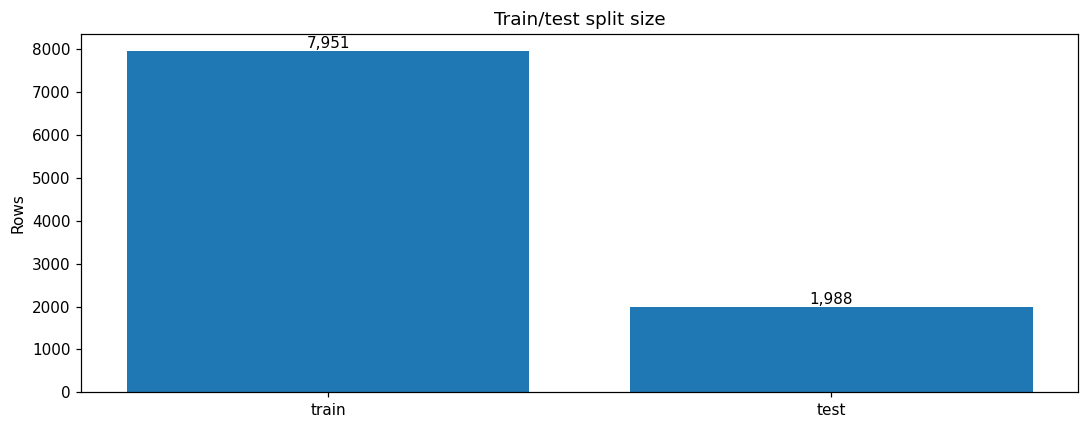

In [8]:
df_order = df.sort_values(TIME_COL).index

X_sorted = X_all.loc[df_order].reset_index(drop=True)
y_sorted = y_all.loc[df_order].reset_index(drop=True)
split_time_sorted = df.loc[df_order, TIME_COL].reset_index(drop=True)

raw_split_idx = int(len(X_sorted) * 0.8)
split_cutoff = split_time_sorted.iloc[raw_split_idx]

# Keep identical timestamps on only one side of the split boundary.
# This avoids having the same scheduled departure timestamp in train and test.
train_mask = split_time_sorted < split_cutoff
test_mask = split_time_sorted >= split_cutoff

X_train = X_sorted.loc[train_mask].copy()
y_train = y_sorted.loc[train_mask].copy()

X_test = X_sorted.loc[test_mask].copy()
y_test = y_sorted.loc[test_mask].copy()

train_time = split_time_sorted.loc[train_mask]
test_time = split_time_sorted.loc[test_mask]
split_idx = len(X_train)

if train_time.max() >= test_time.min():
    raise ValueError("Chronological split boundary overlaps between train and test.")

print(f"Raw 80/20 split index: {raw_split_idx:,}")
print("Split cutoff:", split_cutoff)
print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

print("\nTarget rate:")
display(pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "delay_rate": [y_train.mean(), y_test.mean()],
}).round(4))

print("\nSplit time range:")
print("Train:", train_time.min(), "->", train_time.max())
print("Test: ", test_time.min(), "->", test_time.max())

fig, ax = plt.subplots(figsize=(10, 4))
split_counts = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(y_train), len(y_test)]
})
ax.bar(split_counts["split"], split_counts["rows"])
ax.set_title("Train/test split size")
ax.set_ylabel("Rows")
for i, v in enumerate(split_counts["rows"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_train_test_split_size.png", bbox_inches="tight")
plt.show()


## 6. Preprocessing pipeline

For numeric features:

- median imputation,
- scaling.

For categorical features:

- most frequent imputation,
- one-hot encoding with `handle_unknown='ignore'`.

The preprocessing is inside the pipeline, so it is fitted only on training data.

In [9]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("\nCategorical features:")
print(categorical_features)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

Numeric features: 46
Categorical features: 11

Categorical features:
['dep_iso_region', 'dep_municipality', 'arr_airport_type', 'arr_iso_region', 'arr_municipality', 'dep_iata_grp', 'arr_iata_grp', 'airline_iata_grp', 'route_grp', 'dep_iso_country_grp', 'arr_iso_country_grp']


## 7. Metrics functions

We evaluate every model using:

- ROC-AUC,
- PR-AUC,
- Accuracy,
- Precision,
- Recall,
- F1,
- Brier score.

For this task, PR-AUC, Precision, Recall and F1 are more informative than accuracy alone.

In [10]:
def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    score_min = scores.min()
    score_max = scores.max()

    if score_max == score_min:
        return np.full_like(scores, fill_value=0.5, dtype=float)

    return (scores - score_min) / (score_max - score_min)


def evaluate_model(model, X, y, model_name, threshold=0.5):
    y_proba = get_positive_proba(model, X)
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "brier": brier_score_loss(y, y_proba),
    }

    return metrics, y_pred, y_proba


def plot_confusion_matrix_custom(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["not delayed", "delayed"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_proba, title_prefix):
    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.set_title(f"{title_prefix}: ROC curve")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.set_title(f"{title_prefix}: Precision-Recall curve")
    plt.tight_layout()
    plt.show()

## 8. Baseline models without tuning

We first train understandable baselines:

1. Dummy classifier.
2. Logistic Regression.
3. Random Forest.
4. HistGradientBoosting.

This shows whether complex models and tuning actually improve performance.

In [11]:
baseline_models = {
    "Dummy most_frequent": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
}

baseline_results = []
baseline_fitted = {}

for name, clf in baseline_models.items():
    print(f"\nTraining baseline: {name}")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", clf),
    ])

    pipe.fit(X_train, y_train)

    metrics, y_pred, y_proba = evaluate_model(
        pipe,
        X_test,
        y_test,
        model_name=name,
        threshold=0.5,
    )

    baseline_results.append(metrics)
    baseline_fitted[name] = pipe

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values(["pr_auc", "roc_auc", "f1"], ascending=False)
    .reset_index(drop=True)
)

display(baseline_results_df.round(4))

baseline_results_df.to_csv(DATA_DIR / "02_baseline_model_metrics.csv", index=False)
print("Saved:", DATA_DIR / "02_baseline_model_metrics.csv")


Training baseline: Dummy most_frequent

Training baseline: Logistic Regression

Training baseline: Random Forest

Training baseline: HistGradientBoosting


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
0,Random Forest,0.5,0.6871,0.6778,0.6479,0.6348,0.5787,0.6054,0.2210
1,HistGradientBoosting,0.5,0.6796,0.6594,0.6363,0.6049,0.6369,0.6205,0.2289
2,Logistic Regression,0.5,0.6483,0.6112,0.5966,0.5522,0.7188,0.6245,0.2491
3,Dummy most_frequent,0.5,0.5000,0.4668,0.5332,0.0000,0.0000,0.0000,0.4668


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_baseline_model_metrics.csv


## 9. Best baseline visualization

Best baseline by PR-AUC: Random Forest


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
value,Random Forest,0.5,0.687064,0.677809,0.647887,0.634752,0.578664,0.605411,0.221003


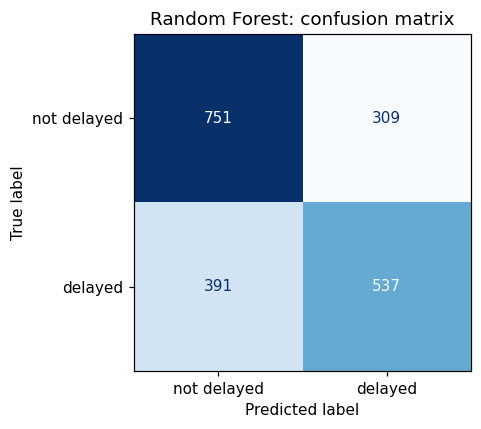

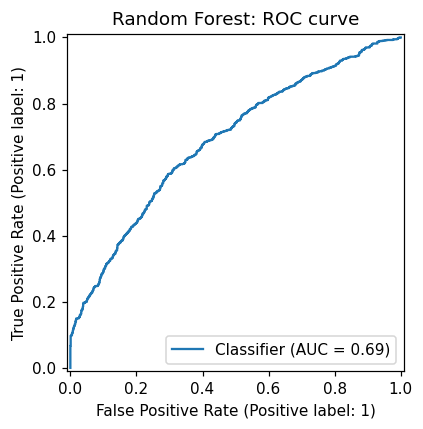

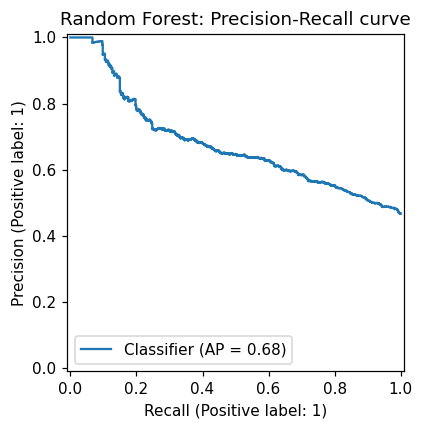

              precision    recall  f1-score   support

 not delayed       0.66      0.71      0.68      1060
     delayed       0.63      0.58      0.61       928

    accuracy                           0.65      1988
   macro avg       0.65      0.64      0.64      1988
weighted avg       0.65      0.65      0.65      1988



In [12]:
best_baseline_name = baseline_results_df.iloc[0]["model"]
best_baseline = baseline_fitted[best_baseline_name]

print("Best baseline by PR-AUC:", best_baseline_name)

best_metrics, best_pred, best_proba = evaluate_model(
    best_baseline,
    X_test,
    y_test,
    model_name=best_baseline_name,
    threshold=0.5,
)

display(pd.Series(best_metrics).to_frame("value").T.round(4))

plot_confusion_matrix_custom(y_test, best_pred, f"{best_baseline_name}: confusion matrix")
plot_roc_pr_curves(y_test, best_proba, best_baseline_name)

print(classification_report(y_test, best_pred, target_names=["not delayed", "delayed"]))

## 10. Hyperparameter tuning

We tune models using `RandomizedSearchCV` and `TimeSeriesSplit`.

Scoring metric: `average_precision`, which is PR-AUC.

The test set is not used during tuning.

In [13]:
tscv = TimeSeriesSplit(n_splits=4)

search_spaces = {
    "Tuned Logistic Regression": {
        "estimator": LogisticRegression(max_iter=4000, random_state=RANDOM_STATE),
        "params": {
            "model__C": np.logspace(-3, 2, 12),
            "model__class_weight": [None, "balanced"],
        },
        "n_iter": 12,
    },

    "Tuned Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [None, 6, 10, 15, 20],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__min_samples_split": [2, 5, 10],
            "model__max_features": ["sqrt", "log2", None],
            "model__class_weight": [None, "balanced"],
        },
        "n_iter": 20,
    },

    "Tuned HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__max_iter": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
        },
        "n_iter": 20,
    },
}

tuned_results = []
tuned_fitted = {}
search_objects = {}

for name, cfg in search_spaces.items():
    print(f"\nTuning: {name}")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", cfg["estimator"]),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="average_precision",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    metrics, y_pred, y_proba = evaluate_model(
        best_model,
        X_test,
        y_test,
        model_name=name,
        threshold=0.5,
    )

    metrics["best_cv_pr_auc"] = search.best_score_
    tuned_results.append(metrics)
    tuned_fitted[name] = best_model
    search_objects[name] = search

    print("Best CV PR-AUC:", round(search.best_score_, 4))
    print("Best params:")
    print(search.best_params_)

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values(["pr_auc", "roc_auc", "f1"], ascending=False)
    .reset_index(drop=True)
)

display(tuned_results_df.round(4))

tuned_results_df.to_csv(DATA_DIR / "02_tuned_model_metrics.csv", index=False)
print("Saved:", DATA_DIR / "02_tuned_model_metrics.csv")


Tuning: Tuned Logistic Regression
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best CV PR-AUC: 0.6496
Best params:
{'model__class_weight': 'balanced', 'model__C': 0.001}

Tuning: Tuned Random Forest
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best CV PR-AUC: 0.6699
Best params:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Tuning: Tuned HistGradientBoosting
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best CV PR-AUC: 0.6524
Best params:
{'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 15, 'model__max_iter': 200, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.0}


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,best_cv_pr_auc
0,Tuned Random Forest,0.5,0.6927,0.6825,0.6368,0.6178,0.5819,0.5993,0.2209,0.6699
1,Tuned HistGradientBoosting,0.5,0.6846,0.6713,0.6308,0.6078,0.5894,0.5985,0.2228,0.6524
2,Tuned Logistic Regression,0.5,0.6767,0.6565,0.6253,0.6004,0.5894,0.5949,0.2264,0.6496


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_tuned_model_metrics.csv


## 11. Compare baseline and tuned models

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,stage,best_cv_pr_auc
0,Tuned Random Forest,0.5,0.6927,0.6825,0.6368,0.6178,0.5819,0.5993,0.2209,tuned,0.6699
1,Random Forest,0.5,0.6871,0.6778,0.6479,0.6348,0.5787,0.6054,0.2210,baseline,NaN
2,Tuned HistGradientBoosting,0.5,0.6846,0.6713,0.6308,0.6078,0.5894,0.5985,0.2228,tuned,0.6524
3,HistGradientBoosting,0.5,0.6796,0.6594,0.6363,0.6049,0.6369,0.6205,0.2289,baseline,NaN
4,Tuned Logistic Regression,0.5,0.6767,0.6565,0.6253,0.6004,0.5894,0.5949,0.2264,tuned,0.6496
5,Logistic Regression,0.5,0.6483,0.6112,0.5966,0.5522,0.7188,0.6245,0.2491,baseline,NaN
6,Dummy most_frequent,0.5,0.5000,0.4668,0.5332,0.0000,0.0000,0.0000,0.4668,baseline,NaN


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_all_model_metrics.csv


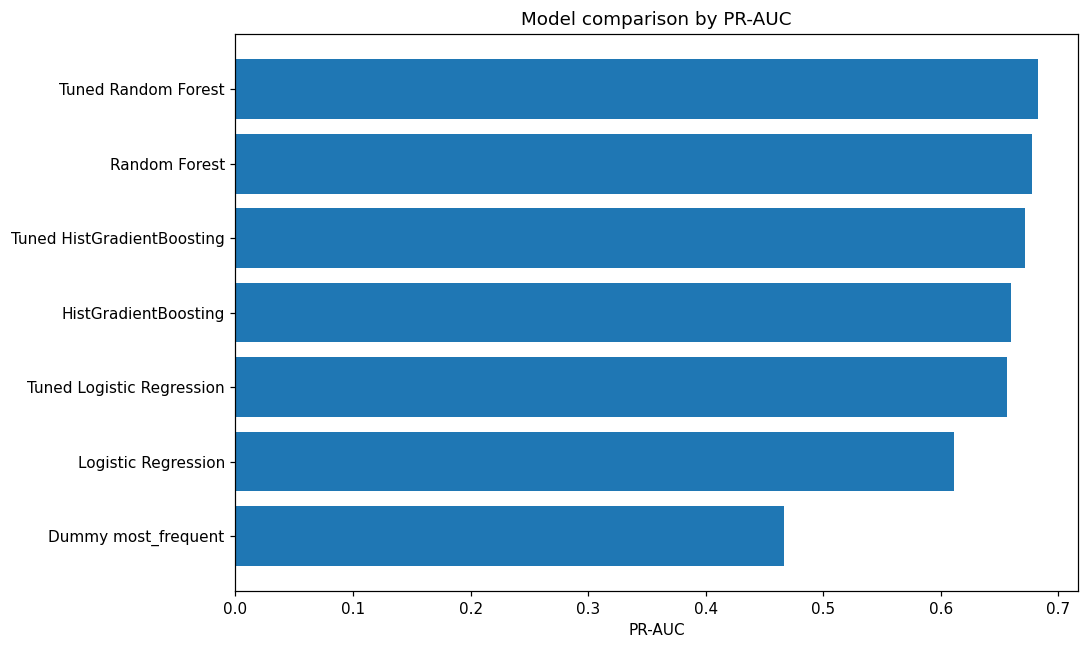

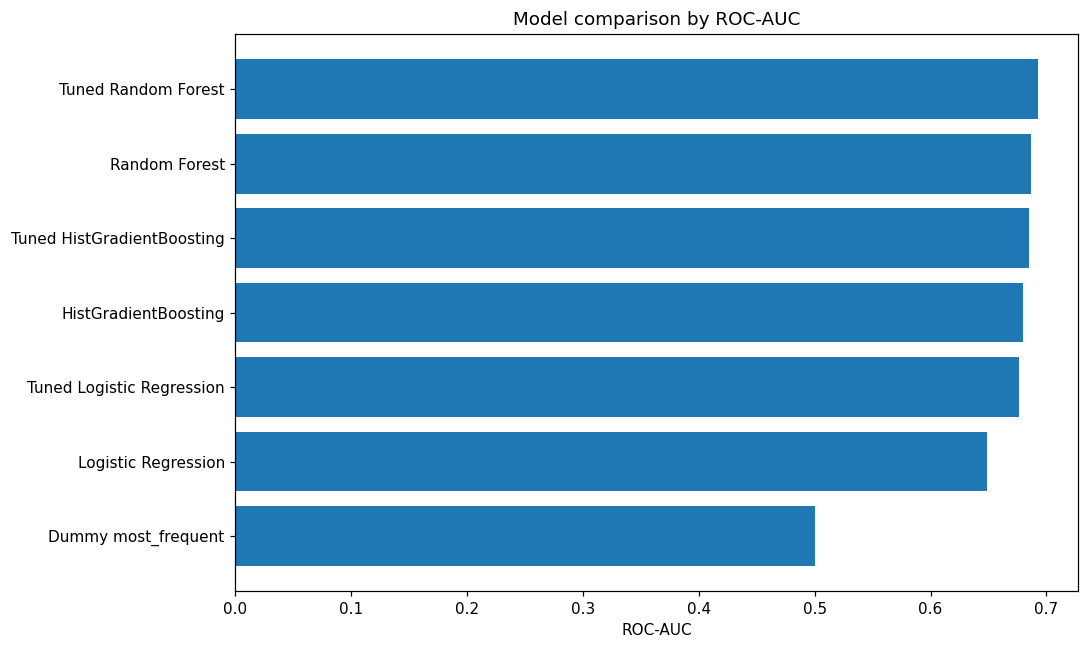

In [14]:
all_results_df = pd.concat(
    [
        baseline_results_df.assign(stage="baseline"),
        tuned_results_df.assign(stage="tuned"),
    ],
    ignore_index=True,
)

all_results_df = all_results_df.sort_values(
    ["pr_auc", "roc_auc", "f1"],
    ascending=False,
).reset_index(drop=True)

display(all_results_df.round(4))

all_results_df.to_csv(DATA_DIR / "02_all_model_metrics.csv", index=False)
print("Saved:", DATA_DIR / "02_all_model_metrics.csv")

plot_df = all_results_df.sort_values("pr_auc", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["model"], plot_df["pr_auc"])
ax.set_xlabel("PR-AUC")
ax.set_title("Model comparison by PR-AUC")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_model_comparison_pr_auc.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["model"], plot_df["roc_auc"])
ax.set_xlabel("ROC-AUC")
ax.set_title("Model comparison by ROC-AUC")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_model_comparison_roc_auc.png", bbox_inches="tight")
plt.show()

## 11.1 Comparative model visualizations

This section adds comparison plots where several models are visible on the same figure.

In [15]:
comparison_df = all_results_df.copy()
comparison_df = comparison_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

display(comparison_df.round(4))

model_registry = {}
model_registry.update(baseline_fitted)
model_registry.update(tuned_fitted)

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,stage,best_cv_pr_auc
0,Tuned Random Forest,0.5,0.6927,0.6825,0.6368,0.6178,0.5819,0.5993,0.2209,tuned,0.6699
1,Random Forest,0.5,0.6871,0.6778,0.6479,0.6348,0.5787,0.6054,0.2210,baseline,NaN
2,Tuned HistGradientBoosting,0.5,0.6846,0.6713,0.6308,0.6078,0.5894,0.5985,0.2228,tuned,0.6524
3,HistGradientBoosting,0.5,0.6796,0.6594,0.6363,0.6049,0.6369,0.6205,0.2289,baseline,NaN
4,Tuned Logistic Regression,0.5,0.6767,0.6565,0.6253,0.6004,0.5894,0.5949,0.2264,tuned,0.6496
5,Logistic Regression,0.5,0.6483,0.6112,0.5966,0.5522,0.7188,0.6245,0.2491,baseline,NaN
6,Dummy most_frequent,0.5,0.5000,0.4668,0.5332,0.0000,0.0000,0.0000,0.4668,baseline,NaN


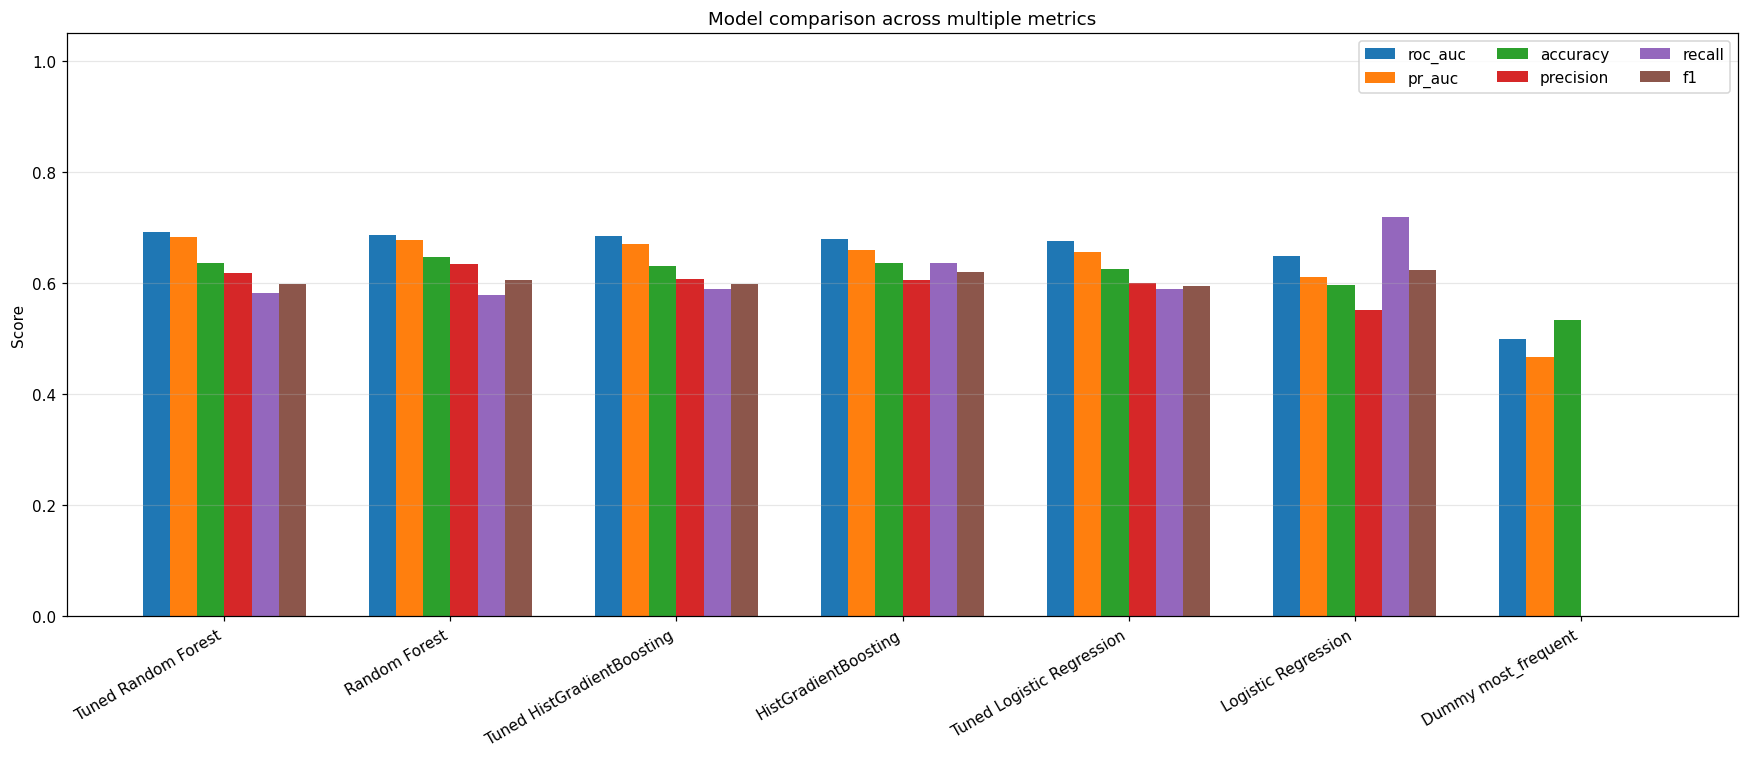

In [16]:
metrics_to_plot = ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]

plot_df = comparison_df.copy()
models = plot_df["model"].tolist()

x = np.arange(len(models))
width = 0.12

fig, ax = plt.subplots(figsize=(16, 7))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(
        x + (i - len(metrics_to_plot) / 2) * width + width / 2,
        plot_df[metric],
        width,
        label=metric
    )

ax.set_title("Model comparison across multiple metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_all_models_grouped_metrics.png", bbox_inches="tight")
plt.show()

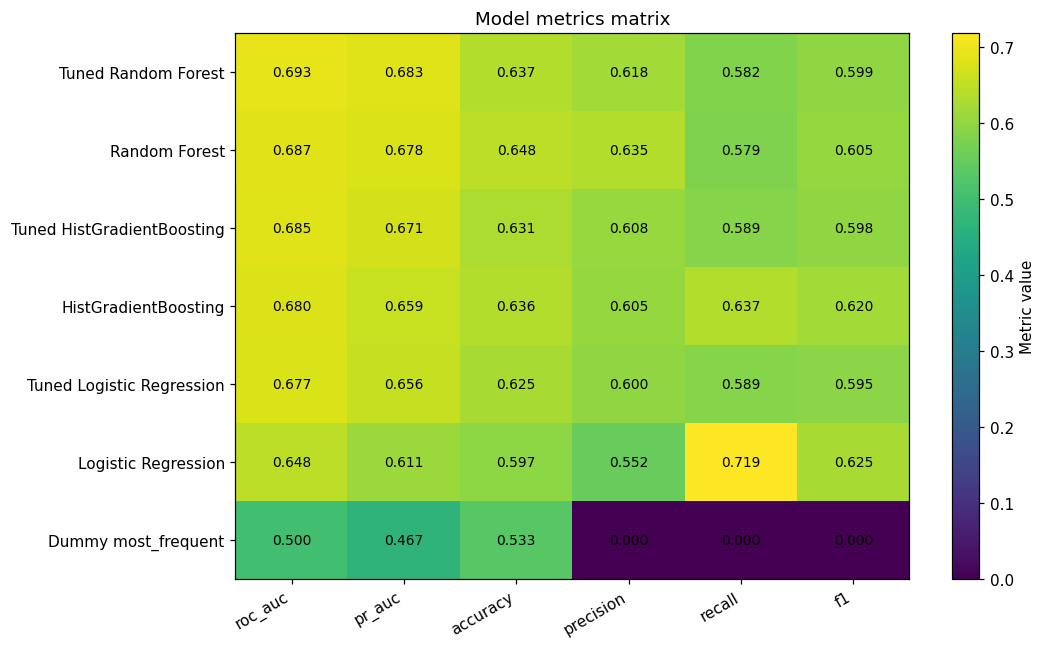

In [17]:
metrics_to_plot = ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]
heatmap_data = comparison_df.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(np.arange(len(metrics_to_plot)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(metrics_to_plot, rotation=30, ha="right")
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=9)

ax.set_title("Model metrics matrix")
fig.colorbar(im, ax=ax, label="Metric value")

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_model_metrics_matrix.png", bbox_inches="tight")
plt.show()

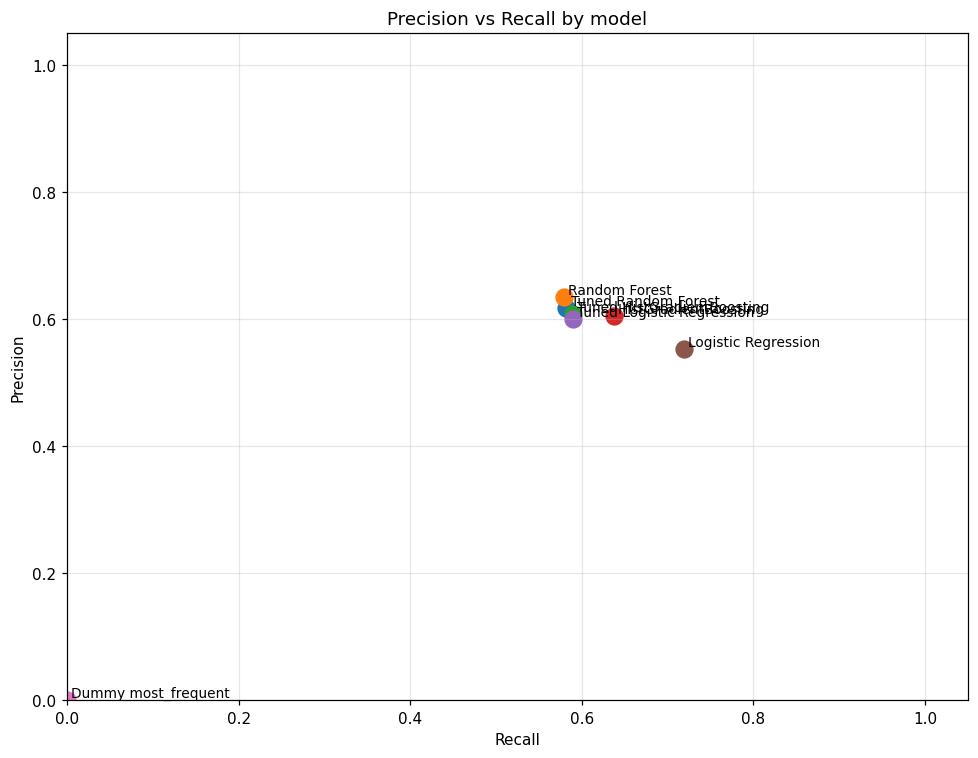

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

for _, row in comparison_df.iterrows():
    ax.scatter(row["recall"], row["precision"], s=120)
    ax.text(
        row["recall"] + 0.005,
        row["precision"] + 0.005,
        row["model"],
        fontsize=9
    )

ax.set_title("Precision vs Recall by model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_precision_vs_recall_models.png", bbox_inches="tight")
plt.show()

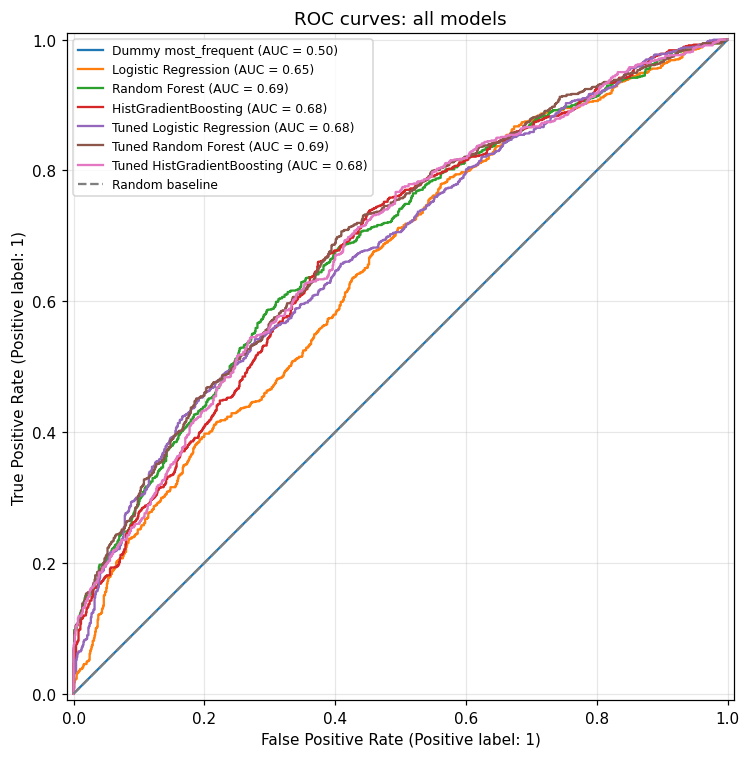

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))

for model_name, model in model_registry.items():
    y_proba = get_positive_proba(model, X_test)
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=model_name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
ax.set_title("ROC curves: all models")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_roc_curves_all_models.png", bbox_inches="tight")
plt.show()

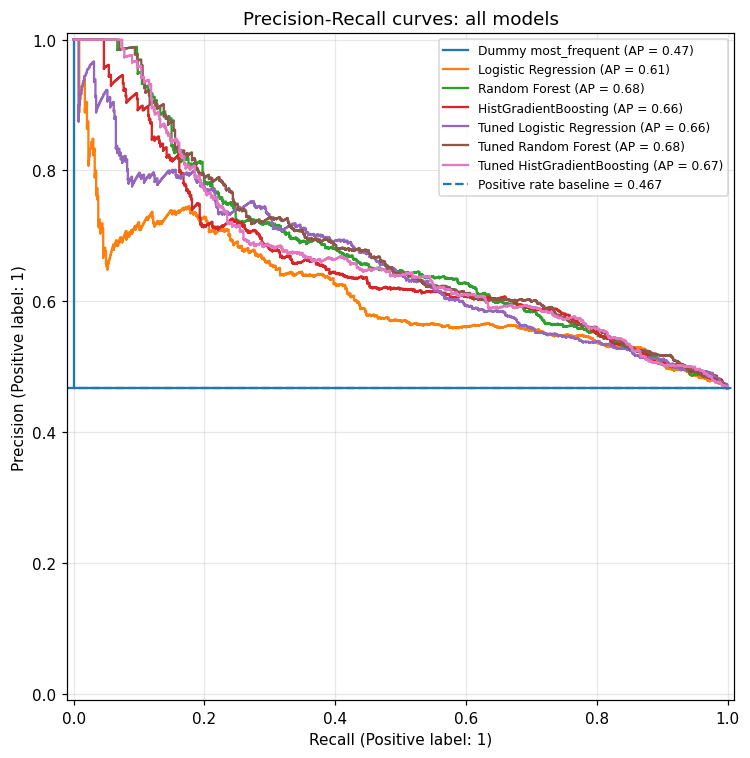

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))

for model_name, model in model_registry.items():
    y_proba = get_positive_proba(model, X_test)
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_proba,
        name=model_name,
        ax=ax
    )

baseline_positive_rate = y_test.mean()
ax.axhline(
    baseline_positive_rate,
    linestyle="--",
    label=f"Positive rate baseline = {baseline_positive_rate:.3f}"
)

ax.set_title("Precision-Recall curves: all models")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_pr_curves_all_models.png", bbox_inches="tight")
plt.show()

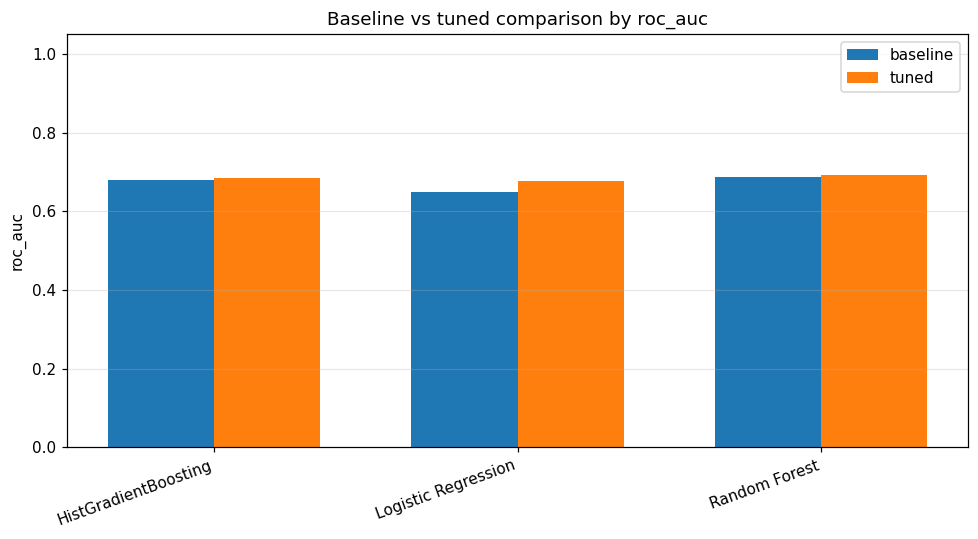

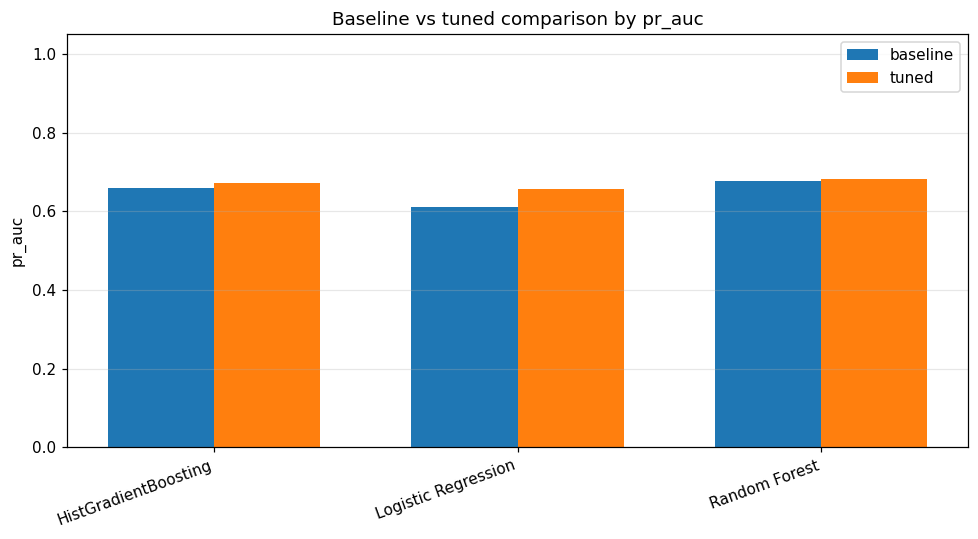

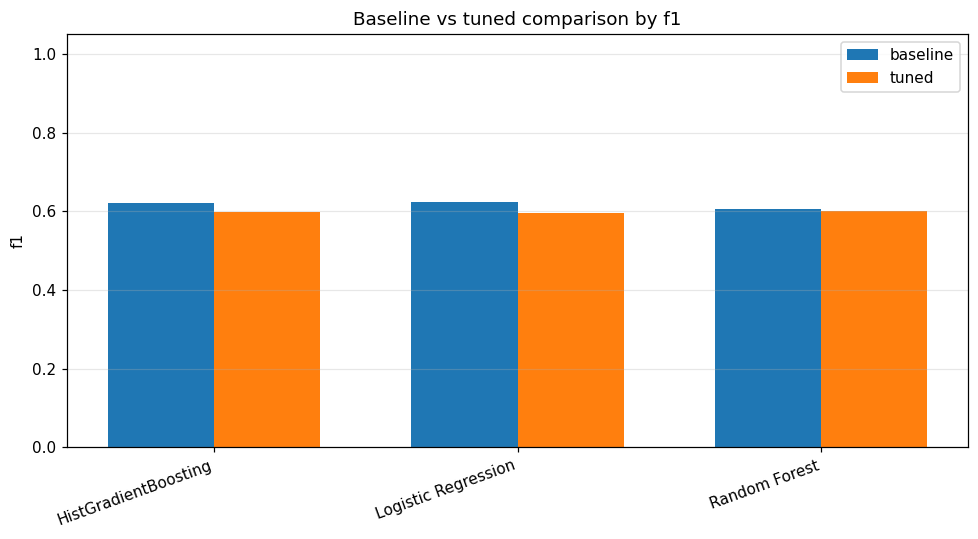

In [21]:
bt_df = all_results_df.copy()

def normalize_model_family(name):
    return name.replace("Tuned ", "")

bt_df["model_family"] = bt_df["model"].apply(normalize_model_family)
bt_df = bt_df[bt_df["model_family"] != "Dummy most_frequent"].copy()

metrics_for_bt = ["roc_auc", "pr_auc", "f1"]

for metric in metrics_for_bt:
    pivot = bt_df.pivot_table(
        index="model_family",
        columns="stage",
        values=metric,
        aggfunc="max"
    )

    existing_cols = [c for c in ["baseline", "tuned"] if c in pivot.columns]
    pivot = pivot[existing_cols]

    fig, ax = plt.subplots(figsize=(9, 5))

    x = np.arange(len(pivot.index))
    width = 0.35

    for i, col in enumerate(pivot.columns):
        ax.bar(
            x + (i - len(pivot.columns) / 2) * width + width / 2,
            pivot[col],
            width,
            label=col
        )

    ax.set_title(f"Baseline vs tuned comparison by {metric}")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(MEDIA_DIR / f"02_baseline_vs_tuned_{metric}.png", bbox_inches="tight")
    plt.show()

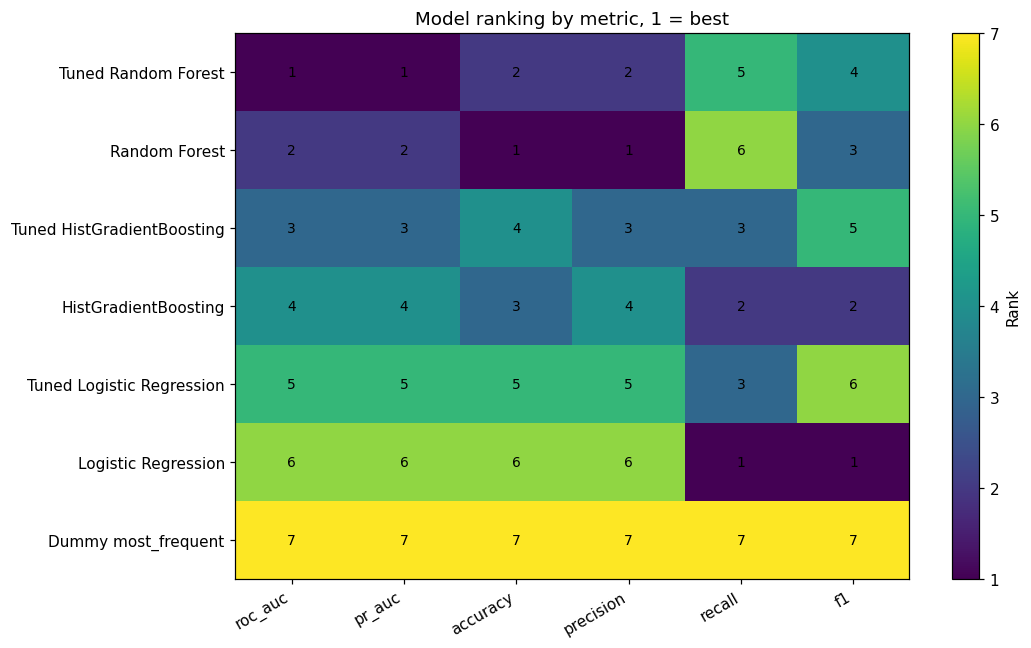

,model,roc_auc_rank,pr_auc_rank,accuracy_rank,precision_rank,recall_rank,f1_rank
0,Tuned Random Forest,1.0,1.0,2.0,2.0,5.0,4.0
1,Random Forest,2.0,2.0,1.0,1.0,6.0,3.0
2,Tuned HistGradientBoosting,3.0,3.0,4.0,3.0,3.0,5.0
3,HistGradientBoosting,4.0,4.0,3.0,4.0,2.0,2.0
4,Tuned Logistic Regression,5.0,5.0,5.0,5.0,3.0,6.0
5,Logistic Regression,6.0,6.0,6.0,6.0,1.0,1.0
6,Dummy most_frequent,7.0,7.0,7.0,7.0,7.0,7.0


In [22]:
ranking_metrics = ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]

rank_df = comparison_df[["model"] + ranking_metrics].copy()

for metric in ranking_metrics:
    rank_df[f"{metric}_rank"] = rank_df[metric].rank(ascending=False, method="min")

rank_cols = [f"{m}_rank" for m in ranking_metrics]
rank_matrix = rank_df.set_index("model")[rank_cols]

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(rank_matrix.values, aspect="auto")

ax.set_xticks(np.arange(len(rank_cols)))
ax.set_yticks(np.arange(len(rank_matrix.index)))

ax.set_xticklabels(ranking_metrics, rotation=30, ha="right")
ax.set_yticklabels(rank_matrix.index)

for i in range(rank_matrix.shape[0]):
    for j in range(rank_matrix.shape[1]):
        value = int(rank_matrix.iloc[i, j])
        ax.text(j, i, str(value), ha="center", va="center", fontsize=9)

ax.set_title("Model ranking by metric, 1 = best")
fig.colorbar(im, ax=ax, label="Rank")

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_model_ranking_by_metric.png", bbox_inches="tight")
plt.show()

display(rank_df[["model"] + rank_cols])

,model,TN,FP,FN,TP,false_positive_rate,false_negative_rate,pr_auc
5,Tuned Random Forest,726,334,388,540,0.3151,0.4181,0.6825
2,Random Forest,751,309,391,537,0.2915,0.4213,0.6778
6,Tuned HistGradientBoosting,707,353,381,547,0.3330,0.4106,0.6713
3,HistGradientBoosting,674,386,337,591,0.3642,0.3631,0.6594
4,Tuned Logistic Regression,696,364,381,547,0.3434,0.4106,0.6565
1,Logistic Regression,519,541,261,667,0.5104,0.2812,0.6112
0,Dummy most_frequent,1060,0,928,0,0.0000,1.0000,0.4668


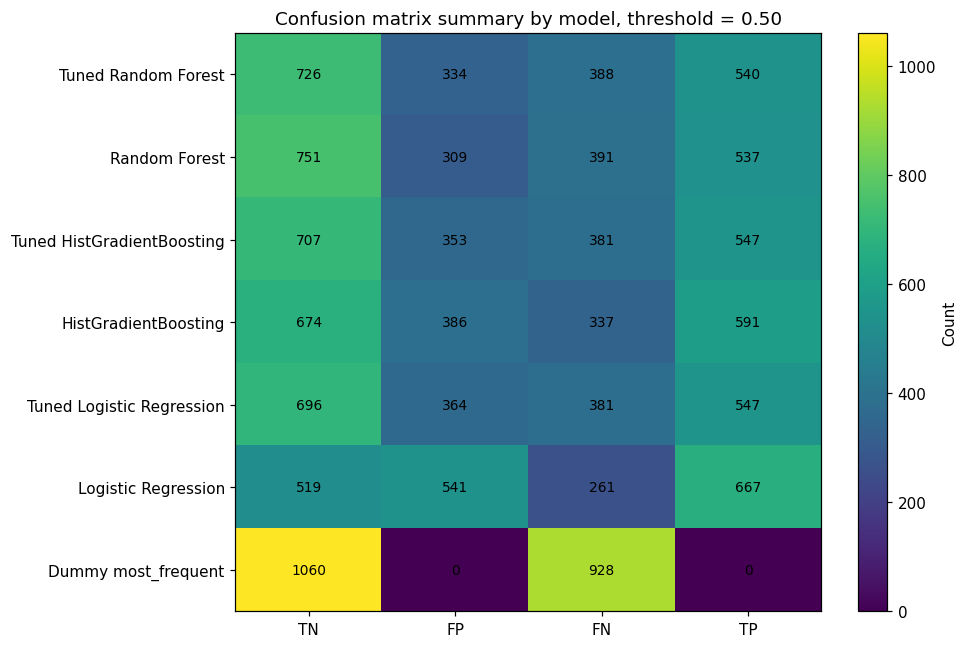

In [23]:
cm_rows = []

for model_name, model in model_registry.items():
    y_proba = get_positive_proba(model, X_test)
    y_pred = (y_proba >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    cm_rows.append({
        "model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
    })

cm_summary_df = pd.DataFrame(cm_rows)
cm_summary_df = cm_summary_df.merge(
    comparison_df[["model", "pr_auc"]],
    on="model",
    how="left"
).sort_values("pr_auc", ascending=False)

display(cm_summary_df.round(4))

cm_summary_df.to_csv(DATA_DIR / "02_confusion_summary_all_models.csv", index=False)

cm_plot_cols = ["TN", "FP", "FN", "TP"]
cm_plot_data = cm_summary_df.set_index("model")[cm_plot_cols]

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(cm_plot_data.values, aspect="auto")

ax.set_xticks(np.arange(len(cm_plot_cols)))
ax.set_yticks(np.arange(len(cm_plot_data.index)))

ax.set_xticklabels(cm_plot_cols)
ax.set_yticklabels(cm_plot_data.index)

for i in range(cm_plot_data.shape[0]):
    for j in range(cm_plot_data.shape[1]):
        value = int(cm_plot_data.iloc[i, j])
        ax.text(j, i, str(value), ha="center", va="center", fontsize=9)

ax.set_title("Confusion matrix summary by model, threshold = 0.50")
fig.colorbar(im, ax=ax, label="Count")

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_confusion_summary_all_models.png", bbox_inches="tight")
plt.show()

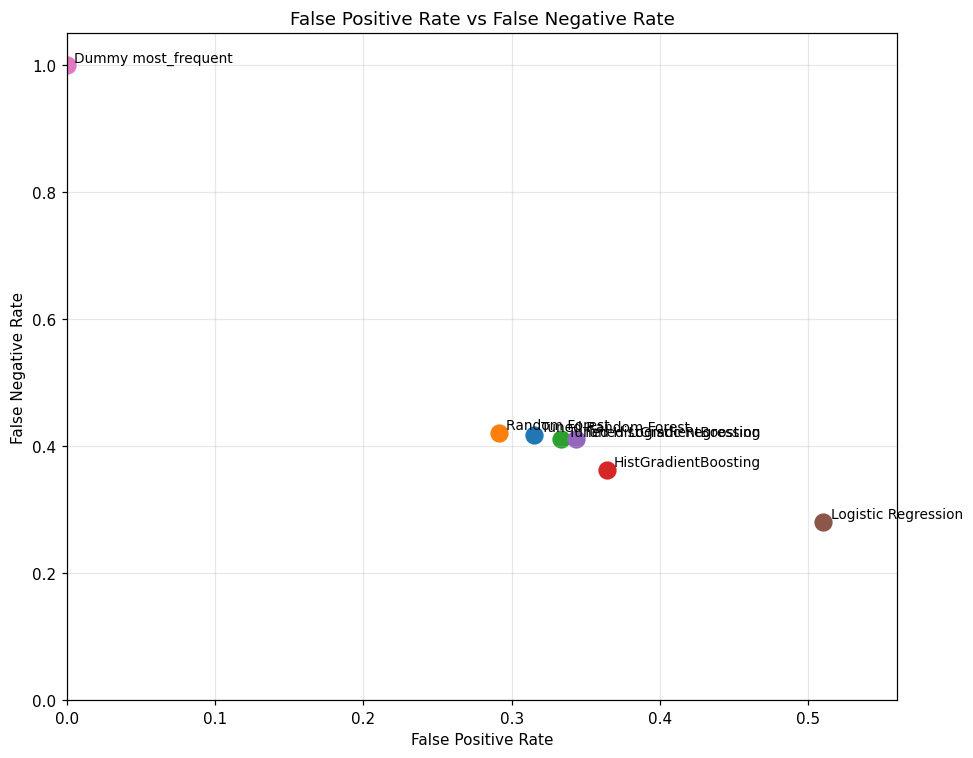

In [24]:
fig, ax = plt.subplots(figsize=(9, 7))

for _, row in cm_summary_df.iterrows():
    ax.scatter(row["false_positive_rate"], row["false_negative_rate"], s=120)
    ax.text(
        row["false_positive_rate"] + 0.005,
        row["false_negative_rate"] + 0.005,
        row["model"],
        fontsize=9
    )

ax.set_title("False Positive Rate vs False Negative Rate")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("False Negative Rate")
ax.set_xlim(0, max(0.05, cm_summary_df["false_positive_rate"].max() + 0.05))
ax.set_ylim(0, max(0.05, cm_summary_df["false_negative_rate"].max() + 0.05))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_fpr_vs_fnr_models.png", bbox_inches="tight")
plt.show()

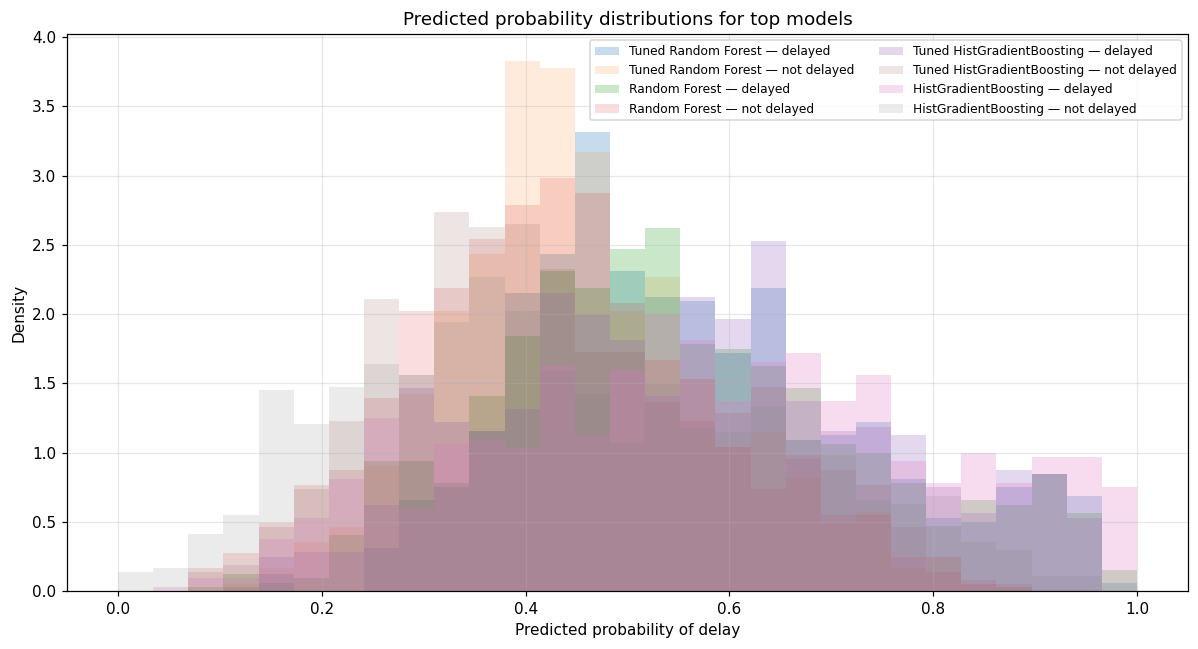

In [25]:
top_model_names = comparison_df["model"].head(4).tolist()

fig, ax = plt.subplots(figsize=(11, 6))

bins = np.linspace(0, 1, 30)

for model_name in top_model_names:
    model = model_registry[model_name]
    y_proba = get_positive_proba(model, X_test)

    ax.hist(
        y_proba[y_test.values == 1],
        bins=bins,
        alpha=0.25,
        density=True,
        label=f"{model_name} — delayed"
    )

    ax.hist(
        y_proba[y_test.values == 0],
        bins=bins,
        alpha=0.15,
        density=True,
        label=f"{model_name} — not delayed"
    )

ax.set_title("Predicted probability distributions for top models")
ax.set_xlabel("Predicted probability of delay")
ax.set_ylabel("Density")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_probability_distributions_top_models.png", bbox_inches="tight")
plt.show()

## 12. Threshold tuning on validation split

The default threshold `0.50` is not always optimal.

We tune threshold on the last 20% of the training period, then evaluate on test.

The selected threshold maximizes precision while enforcing minimum recall and minimum predicted-positive coverage. This avoids a misleading threshold that gets high precision by predicting only a few positive cases.

Selected model by train CV PR-AUC: Tuned Random Forest


,model,best_cv_pr_auc
0,Tuned Random Forest,0.6699
1,Tuned HistGradientBoosting,0.6524
2,Tuned Logistic Regression,0.6496


Best validation threshold by constrained precision:
Minimum recall: 0.25
Minimum predicted-positive rate: 0.03


,threshold,precision,recall,f1,predicted_positive_count,predicted_positive_rate,true_positive_count,false_positive_count,false_negative_count
122,0.66,0.7462,0.2791,0.4063,260.0,0.1634,194.0,66.0,501.0


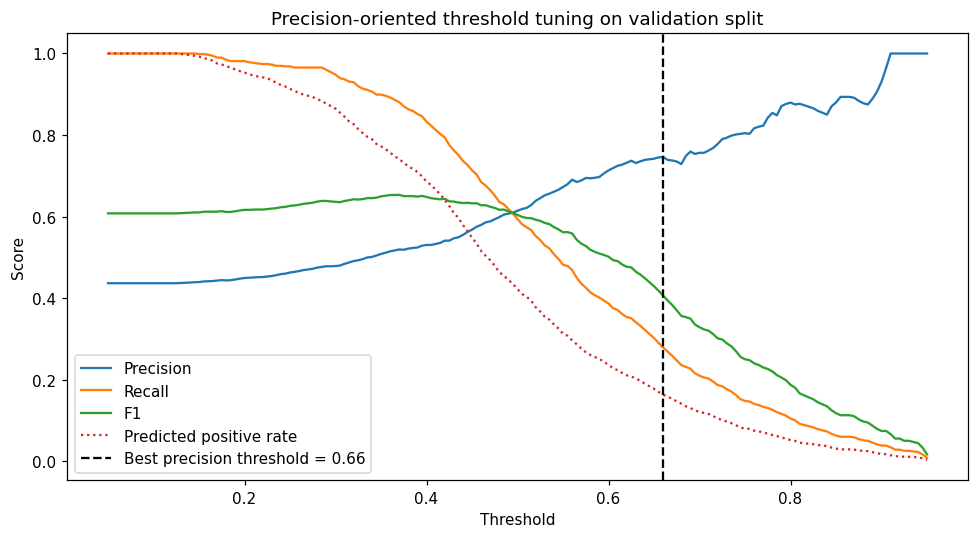

Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_threshold_tuning_validation.csv


In [26]:
cv_selection_df = (
    tuned_results_df
    .dropna(subset=["best_cv_pr_auc"])
    .sort_values("best_cv_pr_auc", ascending=False)
    .reset_index(drop=True)
)

if cv_selection_df.empty:
    raise ValueError("No tuned models with CV scores available for model selection.")

selected_model_name = cv_selection_df.iloc[0]["model"]
selected_model_template = tuned_fitted[selected_model_name]

print("Selected model by train CV PR-AUC:", selected_model_name)
display(cv_selection_df[["model", "best_cv_pr_auc"]].round(4))

PRECISION_MIN_RECALL = 0.25
PRECISION_MIN_PREDICTED_POSITIVE_RATE = 0.03

valid_split_idx = int(len(X_train) * 0.8)

X_subtrain = X_train.iloc[:valid_split_idx]
y_subtrain = y_train.iloc[:valid_split_idx]

X_valid = X_train.iloc[valid_split_idx:]
y_valid = y_train.iloc[valid_split_idx:]

threshold_model = clone(selected_model_template)
threshold_model.fit(X_subtrain, y_subtrain)

valid_proba = get_positive_proba(threshold_model, X_valid)

thresholds = np.linspace(0.05, 0.95, 181)

threshold_rows = []
y_valid_values = y_valid.to_numpy()

for thr in thresholds:
    pred = (valid_proba >= thr).astype(int)
    predicted_positive_count = int(pred.sum())
    true_positive_count = int(((pred == 1) & (y_valid_values == 1)).sum())
    false_positive_count = int(((pred == 1) & (y_valid_values == 0)).sum())
    false_negative_count = int(((pred == 0) & (y_valid_values == 1)).sum())
    threshold_rows.append({
        "threshold": thr,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "f1": f1_score(y_valid, pred, zero_division=0),
        "predicted_positive_count": predicted_positive_count,
        "predicted_positive_rate": predicted_positive_count / len(pred),
        "true_positive_count": true_positive_count,
        "false_positive_count": false_positive_count,
        "false_negative_count": false_negative_count,
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible_thresholds = threshold_df[
    (threshold_df["recall"] >= PRECISION_MIN_RECALL)
    & (threshold_df["predicted_positive_rate"] >= PRECISION_MIN_PREDICTED_POSITIVE_RATE)
]

if eligible_thresholds.empty:
    raise ValueError(
        "No threshold satisfies the precision constraints: "
        f"recall >= {PRECISION_MIN_RECALL:.3f} and "
        f"predicted_positive_rate >= {PRECISION_MIN_PREDICTED_POSITIVE_RATE:.3f}."
    )

best_precision_row = eligible_thresholds.sort_values(
    ["precision", "recall", "f1", "predicted_positive_rate"],
    ascending=False,
).iloc[0]
best_threshold = float(best_precision_row["threshold"])
threshold_selection_validation = {
    key: int(value) if key.endswith("_count") else float(value)
    for key, value in best_precision_row.to_dict().items()
}

print("Best validation threshold by constrained precision:")
print("Minimum recall:", PRECISION_MIN_RECALL)
print("Minimum predicted-positive rate:", PRECISION_MIN_PREDICTED_POSITIVE_RATE)
display(best_precision_row.to_frame().T.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.plot(threshold_df["threshold"], threshold_df["predicted_positive_rate"], label="Predicted positive rate", linestyle=":")
ax.axvline(best_threshold, linestyle="--", color="black", label=f"Best precision threshold = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision-oriented threshold tuning on validation split")
ax.legend()
plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_threshold_tuning_validation.png", bbox_inches="tight")
plt.show()

threshold_df.to_csv(DATA_DIR / "02_threshold_tuning_validation.csv", index=False)
print("Saved:", DATA_DIR / "02_threshold_tuning_validation.csv")

In [27]:
threshold_candidates = eligible_thresholds.sort_values(
    ["precision", "recall", "f1", "predicted_positive_rate"],
    ascending=False,
).head(10)

print("Top validation thresholds by constrained precision ranking:")
display(threshold_candidates.round(4))

Top validation thresholds by constrained precision ranking:


,threshold,precision,recall,f1,predicted_positive_count,predicted_positive_rate,true_positive_count,false_positive_count,false_negative_count
122,0.660,0.7462,0.2791,0.4063,260,0.1634,194,66,501
121,0.655,0.7454,0.2906,0.4182,271,0.1703,202,69,493
120,0.650,0.7420,0.3022,0.4294,283,0.1779,210,73,485
119,0.645,0.7406,0.3122,0.4393,293,0.1842,217,76,478
118,0.640,0.7393,0.3223,0.4489,303,0.1904,224,79,471
123,0.665,0.7391,0.2691,0.3945,253,0.1590,187,66,508
124,0.670,0.7377,0.2590,0.3834,244,0.1534,180,64,515
115,0.625,0.7372,0.3511,0.4756,331,0.2080,244,87,451
117,0.635,0.7357,0.3324,0.4579,314,0.1974,231,83,464
114,0.620,0.7321,0.3540,0.4772,336,0.2112,246,90,449


## 13. Final selected model evaluation on test

We refit the selected model on the full training period and evaluate on the test period.

We compare:

- threshold = 0.50,
- precision-tuned threshold.

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
0,Tuned Random Forest / threshold 0.50,0.50,0.6927,0.6825,0.6368,0.6178,0.5819,0.5993,0.2209
1,Tuned Random Forest / precision-tuned threshol...,0.66,0.6927,0.6825,0.6112,0.7385,0.2586,0.3831,0.2209


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_final_selected_model_metrics.csv


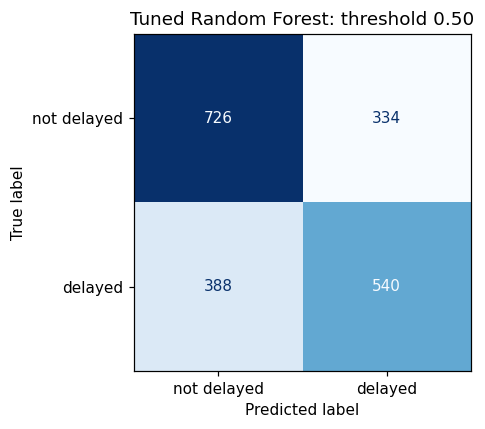

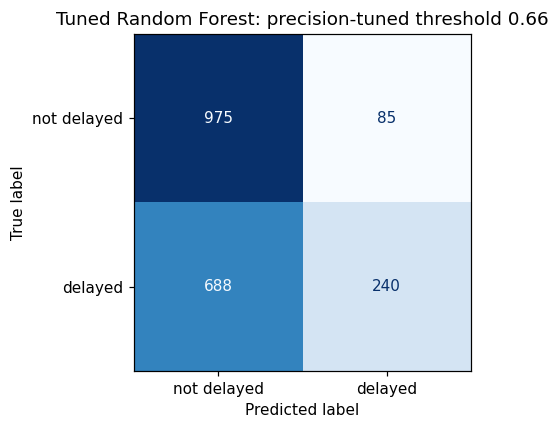

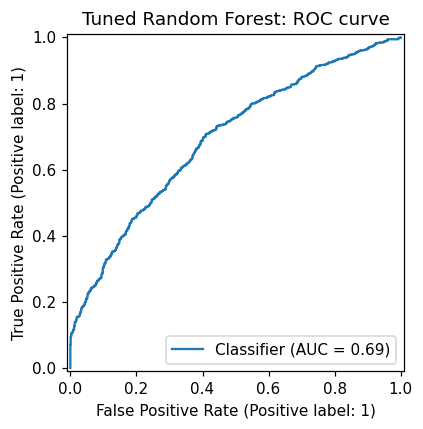

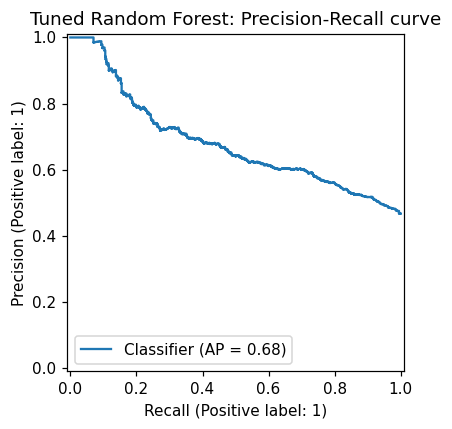

Classification report with precision-tuned threshold:
              precision    recall  f1-score   support

 not delayed       0.59      0.92      0.72      1060
     delayed       0.74      0.26      0.38       928

    accuracy                           0.61      1988
   macro avg       0.66      0.59      0.55      1988
weighted avg       0.66      0.61      0.56      1988



In [28]:
final_model = clone(selected_model_template)
final_model.fit(X_train, y_train)

final_metrics_05, final_pred_05, final_proba = evaluate_model(
    final_model,
    X_test,
    y_test,
    model_name=f"{selected_model_name} / threshold 0.50",
    threshold=0.5,
)

final_metrics_tuned, final_pred_tuned, _ = evaluate_model(
    final_model,
    X_test,
    y_test,
    model_name=f"{selected_model_name} / precision-tuned threshold {best_threshold:.2f}",
    threshold=best_threshold,
)

final_eval_df = pd.DataFrame([final_metrics_05, final_metrics_tuned])
display(final_eval_df.round(4))

final_eval_df.to_csv(DATA_DIR / "02_final_selected_model_metrics.csv", index=False)
print("Saved:", DATA_DIR / "02_final_selected_model_metrics.csv")

plot_confusion_matrix_custom(y_test, final_pred_05, f"{selected_model_name}: threshold 0.50")
plot_confusion_matrix_custom(y_test, final_pred_tuned, f"{selected_model_name}: precision-tuned threshold {best_threshold:.2f}")

plot_roc_pr_curves(y_test, final_proba, selected_model_name)

print("Classification report with precision-tuned threshold:")
print(classification_report(y_test, final_pred_tuned, target_names=["not delayed", "delayed"]))

## 14. Permutation importance

This is model-agnostic feature importance.

It shows which original features decrease PR-AUC the most when shuffled.

,feature,importance_mean,importance_std
11,route_distance_km,0.00462,0.00112
55,dep_iso_country_grp,0.00459,0.00122
31,dep_airport_delay_rate_7d,0.00204,0.00087
21,flights_dep_same_hour,0.00199,0.00098
1,dep_longitude,0.00181,0.00056
24,route_avg_delay_30d,0.00181,0.00072
23,route_avg_delay_7d,0.00163,0.00233
27,airline_avg_delay_30d,0.00160,0.00104
28,airline_delay_rate_7d,0.00157,0.00198
30,dep_airport_avg_delay_30d,0.00153,0.00062


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_permutation_importance.csv


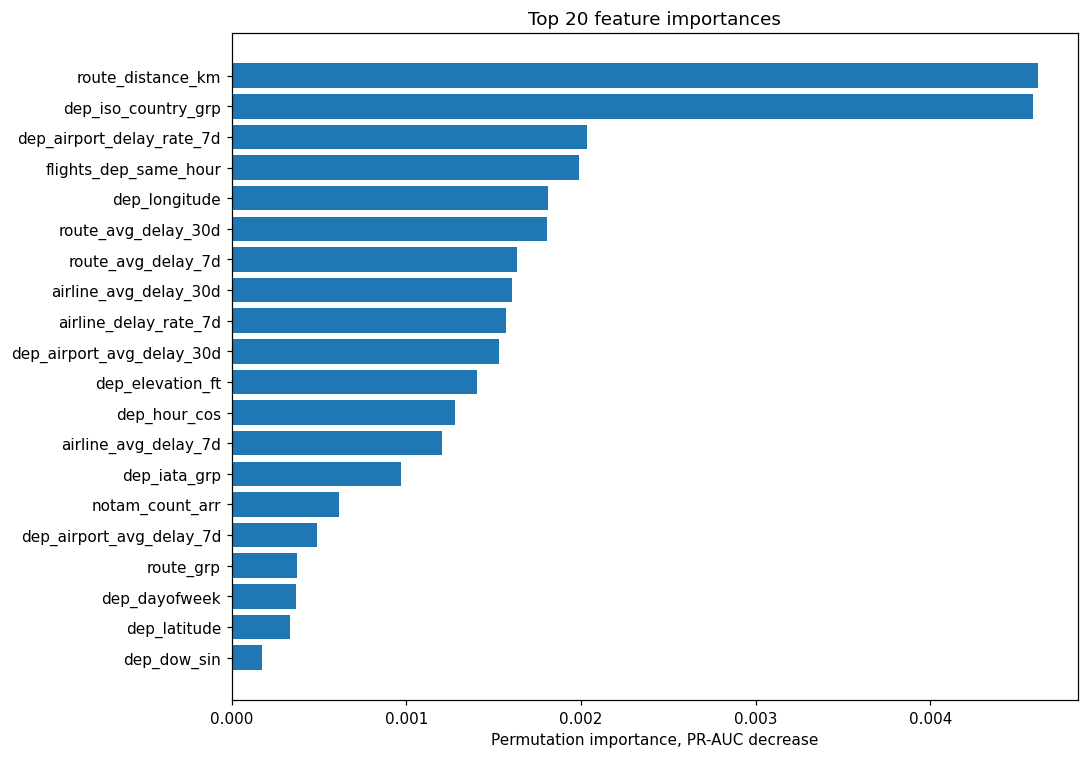

In [29]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(30).round(5))

perm_df.to_csv(DATA_DIR / "02_permutation_importance.csv", index=False)
print("Saved:", DATA_DIR / "02_permutation_importance.csv")

fig, ax = plt.subplots(figsize=(10, 7))
top_perm = perm_df.head(20).sort_values("importance_mean", ascending=True)
ax.barh(top_perm["feature"], top_perm["importance_mean"])
ax.set_xlabel("Permutation importance, PR-AUC decrease")
ax.set_title("Top 20 feature importances")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "02_permutation_importance_top20.png", bbox_inches="tight")
plt.show()

## 15. Error analysis

We inspect:

- false negatives: real delay, model predicted no delay,
- false positives: no delay, model predicted delay.

False negatives are important because missing a real delay can be more harmful operationally.

In [30]:
test_original = df.loc[df_order].reset_index(drop=True).iloc[split_idx:].copy()

test_original["y_true"] = y_test.values
test_original["y_proba"] = final_proba
test_original["y_pred_tuned"] = final_pred_tuned

test_original["error_type"] = np.select(
    [
        (test_original["y_true"] == 1) & (test_original["y_pred_tuned"] == 0),
        (test_original["y_true"] == 0) & (test_original["y_pred_tuned"] == 1),
        (test_original["y_true"] == test_original["y_pred_tuned"]),
    ],
    [
        "false_negative",
        "false_positive",
        "correct",
    ],
    default="unknown",
)

print("Error type distribution:")
display(test_original["error_type"].value_counts().to_frame("count"))

preferred_cols = [
    "dep_scheduled_utc",
    "dep_iata",
    "arr_iata",
    "airline_iata",
    "route",
    "route_distance_km",
    "is_domestic",
    "is_international",
    "dep_hour",
    "dep_dayofweek",
    "notam_count_dep",
    "notam_count_arr",
    "notam_count_route",
    "flights_dep_same_hour",
    "flights_arr_same_hour",
    "dep_delay_min",
    "y_true",
    "y_proba",
    "y_pred_tuned",
    "error_type",
]

preferred_cols = [c for c in preferred_cols if c in test_original.columns]

print("\nFalse negatives with highest predicted probability:")
display(
    test_original[test_original["error_type"] == "false_negative"]
    .sort_values("y_proba", ascending=False)
    [preferred_cols]
    .head(20)
)

print("\nFalse positives with highest predicted probability:")
display(
    test_original[test_original["error_type"] == "false_positive"]
    .sort_values("y_proba", ascending=False)
    [preferred_cols]
    .head(20)
)

test_original.to_csv(DATA_DIR / "02_test_error_analysis.csv", index=False)
print("Saved:", DATA_DIR / "02_test_error_analysis.csv")

Error type distribution:


,count
error_type,
correct,1215
false_negative,688
false_positive,85



False negatives with highest predicted probability:


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,route,route_distance_km,dep_hour,dep_dayofweek,notam_count_dep,notam_count_arr,notam_count_route,flights_dep_same_hour,flights_arr_same_hour,dep_delay_min,y_true,y_proba,y_pred_tuned,error_type
9919,2026-05-10 23:10:00+00:00,ALA,ICN,OZ,ALA_ICN,4172.17,23,6,11,0.0,11,8,10,33.0,1,0.657343,0,false_negative
9067,2026-05-08 23:00:00+00:00,IST,CIT,DV,IST_CIT,3345.89,23,4,0,3.0,3,1,0,26.0,1,0.656604,0,false_negative
8417,2026-05-06 05:30:00+00:00,NQZ,DXB,FZ,NQZ_DXB,3177.40,5,2,11,0.0,11,5,8,35.0,1,0.656364,0,false_negative
8911,2026-05-08 15:25:00+00:00,ALA,LGG,D0,ALA_LGG,5275.19,15,4,15,0.0,15,3,15,36.0,1,0.655897,0,false_negative
9090,2026-05-08 23:50:00+00:00,ALA,LEJ,AG,ALA_LEJ,4797.15,23,4,12,0.0,12,10,10,18.0,1,0.654295,0,false_negative
9608,2026-05-10 06:30:00+00:00,ALA,IST,TK,ALA_IST,3923.13,6,6,14,0.0,14,13,1,26.0,1,0.652473,0,false_negative
9072,2026-05-08 23:10:00+00:00,ALA,ICN,OZ,ALA_ICN,4172.17,23,4,12,0.0,12,10,10,40.0,1,0.652166,0,false_negative
8768,2026-05-08 06:30:00+00:00,ALA,IST,TK,ALA_IST,3923.13,6,4,21,0.0,21,11,2,20.0,1,0.651613,0,false_negative
9409,2026-05-09 20:20:00+00:00,WAW,NQZ,LO,WAW_NQZ,3419.25,20,5,0,9.0,9,1,0,56.0,1,0.651332,0,false_negative
8418,2026-05-06 05:30:00+00:00,NQZ,DXB,EK,NQZ_DXB,3177.40,5,2,11,0.0,11,5,8,35.0,1,0.651061,0,false_negative



False positives with highest predicted probability:


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,route,route_distance_km,dep_hour,dep_dayofweek,notam_count_dep,notam_count_arr,notam_count_route,flights_dep_same_hour,flights_arr_same_hour,dep_delay_min,y_true,y_proba,y_pred_tuned,error_type
8199,2026-04-30 08:45:00+00:00,IST,ALA,TK,IST_ALA,3923.13,8,3,0,29.0,29,2,0,6.0,0,0.878123,1,false_positive
9108,2026-05-09 00:40:00+00:00,IST,ALA,TK,IST_ALA,3923.13,0,5,0,12.0,12,3,0,13.0,0,0.841738,1,false_positive
8399,2026-05-06 00:10:00+00:00,IST,ALA,TK,IST_ALA,3923.13,0,2,0,12.0,12,3,0,10.0,0,0.828408,1,false_positive
9110,2026-05-09 00:40:00+00:00,IST,ALA,KC,IST_ALA,3923.13,0,5,0,12.0,12,3,0,13.0,0,0.815882,1,false_positive
9109,2026-05-09 00:40:00+00:00,IST,ALA,MS,IST_ALA,3923.13,0,5,0,12.0,12,3,0,13.0,0,0.811885,1,false_positive
8756,2026-05-08 05:55:00+00:00,PVG,CIT,DV,PVG_CIT,4747.56,5,4,0,6.0,6,2,0,12.0,0,0.811833,1,false_positive
8316,2026-05-04 17:40:00+00:00,IST,ALA,TK,IST_ALA,3923.13,17,0,0,15.0,15,3,0,7.0,0,0.810471,1,false_positive
8400,2026-05-06 00:10:00+00:00,IST,ALA,MS,IST_ALA,3923.13,0,2,0,12.0,12,3,0,10.0,0,0.806097,1,false_positive
9795,2026-05-10 17:40:00+00:00,IST,ALA,TK,IST_ALA,3923.13,17,6,0,11.0,11,2,0,12.0,0,0.805728,1,false_positive
8202,2026-04-30 09:00:00+00:00,IST,ALA,MB,IST_ALA,3923.13,9,3,0,30.0,30,1,3,8.0,0,0.800271,1,false_positive


Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\02_test_error_analysis.csv


## 16. Save final model and metadata

In [31]:
model_path = MODEL_DIR / "flight_delay_classifier.joblib"
metadata_path = MODEL_DIR / "flight_delay_classifier_metadata.json"

joblib.dump(final_model, model_path)

metadata = {
    "target": TARGET_COL,
    "positive_class": "departure delay > 15 minutes",
    "selected_model": selected_model_name,
    "split_strategy": split_strategy_note,
    "default_threshold": 0.5,
    "tuned_threshold": best_threshold,
    "threshold_objective": "maximize precision subject to validation recall and coverage constraints",
    "threshold_constraints": {
        "min_recall": PRECISION_MIN_RECALL,
        "min_predicted_positive_rate": PRECISION_MIN_PREDICTED_POSITIVE_RATE,
    },
    "threshold_selection_validation": threshold_selection_validation,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_delay_rate": float(y_train.mean()),
    "test_delay_rate": float(y_test.mean()),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "dropped_forbidden_columns": present_forbidden,
    "dropped_raw_high_cardinality_columns": raw_cols_to_drop,
    "dropped_helper_int_columns": helper_int_cols_to_drop,
    "retained_rolling_history_columns": present_rolling_history_cols,
    "retained_rolling_missing_flags": present_rolling_missing_flags,
    "dropped_constant_columns": constant_cols,
    "dropped_near_constant_columns": near_constant_cols,
    "final_metrics_threshold_05": final_metrics_05,
    "final_metrics_tuned_threshold": final_metrics_tuned,
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)

Saved model: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models\flight_delay_classifier.joblib
Saved metadata: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models\flight_delay_classifier_metadata.json


## 17. Final summary for report

In [32]:
summary = f'''
Model training summary

Dataset:
- Source file: {CLEAN_PATH}
- Rows after EDA cleaning: {len(df):,}
- Features used for training: {X_train.shape[1]:,}
- Rolling historical features retained: {len(present_rolling_history_cols)}
- Rolling missingness flags retained: {len(present_rolling_missing_flags)}
- Train rows: {len(X_train):,}
- Test rows: {len(X_test):,}
- Train delay rate: {y_train.mean():.3f}
- Test delay rate: {y_test.mean():.3f}

Validation:
- Split strategy: {split_strategy_note}
- Hyperparameter tuning: RandomizedSearchCV with TimeSeriesSplit
- Model tuning metric: PR-AUC / average precision
- Threshold objective: maximize precision subject to recall >= {PRECISION_MIN_RECALL:.2f} and predicted-positive rate >= {PRECISION_MIN_PREDICTED_POSITIVE_RATE:.2f}
- Selected validation threshold: {best_threshold:.3f}
- Selected validation precision: {threshold_selection_validation["precision"]:.4f}
- Selected validation recall: {threshold_selection_validation["recall"]:.4f}

Best selected model:
- {selected_model_name}

Final test metrics with threshold 0.50:
- ROC-AUC: {final_metrics_05["roc_auc"]:.4f}
- PR-AUC: {final_metrics_05["pr_auc"]:.4f}
- Accuracy: {final_metrics_05["accuracy"]:.4f}
- Precision: {final_metrics_05["precision"]:.4f}
- Recall: {final_metrics_05["recall"]:.4f}
- F1: {final_metrics_05["f1"]:.4f}
- Brier score: {final_metrics_05["brier"]:.4f}

Final test metrics with precision-tuned threshold {best_threshold:.3f}:
- ROC-AUC: {final_metrics_tuned["roc_auc"]:.4f}
- PR-AUC: {final_metrics_tuned["pr_auc"]:.4f}
- Accuracy: {final_metrics_tuned["accuracy"]:.4f}
- Precision: {final_metrics_tuned["precision"]:.4f}
- Recall: {final_metrics_tuned["recall"]:.4f}
- F1: {final_metrics_tuned["f1"]:.4f}
- Brier score: {final_metrics_tuned["brier"]:.4f}

Important:
- The cleaned dataset was created in 01_eda.ipynb.
- This notebook does not repeat full EDA cleaning.
- dep_scheduled_utc was used only for chronological splitting, not as a feature.
- Leakage guard removed forbidden columns if they remained in the cleaned CSV.
- Raw high-cardinality columns were dropped when grouped versions existed.
- The model was saved to {model_path}.
'''

print(summary)

summary_path = DATA_DIR / "02_training_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print("Saved:", summary_path)


Model training summary

Dataset:
- Source file: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\flight_features_cleaned_for_modeling.csv
- Rows after EDA cleaning: 9,939
- Features used for training: 57
- Rolling historical features retained: 9
- Rolling missingness flags retained: 9
- Train rows: 7,951
- Test rows: 1,988
- Train delay rate: 0.455
- Test delay rate: 0.467

Validation:
- Split strategy: Chronological split using dep_scheduled_utc from cleaned dataset. The timestamp is used only for sorting and is not used as a model feature.
- Hyperparameter tuning: RandomizedSearchCV with TimeSeriesSplit
- Model tuning metric: PR-AUC / average precision
- Threshold objective: maximize precision subject to recall >= 0.25 and predicted-positive rate >= 0.03
- Selected validation threshold: 0.660
- Selected validation precision: 0.7462
- Selected validation recall: 0.2791

Best selected model:
- Tuned Random Forest

Final test metrics with threshold 0.50:
- ROC-AUC: